# Feature Engineering 2.0
built upon 1.1.1 dataset 

In [1]:
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from src.features import transformers
import pandas as pd
from sklearn import set_config
set_config(transform_output="pandas")


In [2]:
#loading files
dataset_path = "../data/interim/fe_1_1_1_data.pkl"
pipeline_path = "../data/interim/models/1_1_1_data_pipeline.pkl"

df = joblib.load(dataset_path)
pipeline = joblib.load(pipeline_path)


In [3]:
df.head()

,age,sex,height_inches,weight_pounds,bmi,num_people_in_house,sw_num_days_per_week,irreg_sched,sw_9am_start_diff,sw_5pm_end_diff,...,difficulty_operating_motor_vehicles_for_long_distances_fosq,difficulty_visiting_family_or_friends_in_their_home_fosq,relationships_with_family_or_friends_affected_fosq,difficulty_watching_a_movie_fosq,difficulty_being_active_in_evening_fosq,difficulty_being_active_in_morning_fosq,effect_on_desire_for_intimacy_or_sex_fosq,fosq_summary_score,type_of_pap_device,ahi
0,30,F,67,188.0,29.4,4,<NA>,False,-1.00,0.0,...,2,1,1,2,1.0,1.0,2,8,<NA>,0.4
1,30,F,67,165.0,25.8,3,3,True,-2.00,2.0,...,4,3,3,3,3.0,3.0,3,14,<NA>,1.0
2,42,M,64,156.0,26.8,0,7,True,-3.00,3.0,...,4,3,4,3,2.0,2.0,4,16,<NA>,3.9
3,36,M,63,255.0,45.2,3,5,True,-0.75,0.5,...,4,4,3,3,2.0,2.0,2,15,False,1.3
4,41,F,66,186.0,30.0,6,<NA>,None,NaN,NaN,...,<NA>,<NA>,<NA>,<NA>,NaN,NaN,<NA>,<NA>,<NA>,2.5


In [4]:
rfc_model = RandomForestClassifier(random_state=42)



X = df.drop("ahi", axis=1)

datetime_cols = X.select_dtypes(include=["datetime", "datetime64"]).columns

X = X.drop(columns=datetime_cols)


y = df["ahi"].where(df["ahi"] >= 5, 1).where(df["ahi"] < 5, 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_transformed = pipeline.transform(X_train)
X_test_transformed = pipeline.transform(X_test)

rfc_model.fit(X_train_transformed, y_train)


/Users/jack/Repos/apnea-predictor/src/features/transformers.py:145: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[False False False ... True False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X_transformed.loc[:, self.columns] = self.imputer.transform(
/Users/jack/Repos/apnea-predictor/src/features/transformers.py:145: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X_transformed.loc[:, self.columns] = self.imputer.transform(
/Users/jack/Repos/apnea-predictor/src/features/transformers.py:145: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[True True True ... False True True]' has dtype incompatibl

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [5]:
# TODO: this doesnt get full list of features gah

feature_names = X_train_transformed.columns.tolist()
importances = rfc_model.feature_importances_
feature_importance_df = pd.DataFrame({"feature": feature_names, "importance": importances}
 ).sort_values(by="importance", ascending=False)


In [6]:
import xgboost as xgb
import shap


model = xgb.XGBClassifier(random_state=42, n_estimators=1000, max_depth=6, learning_rate=0.01, subsample=0.8, colsample_bytree=0.8)
model.fit(X_train_transformed, y_train)

preds = model.predict(X_test_transformed)
print(classification_report(y_test, preds))


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


              precision    recall  f1-score   support

         0.0       0.73      0.97      0.83       256
         1.0       0.53      0.08      0.14       101

    accuracy                           0.72       357
   macro avg       0.63      0.53      0.49       357
weighted avg       0.67      0.72      0.64       357



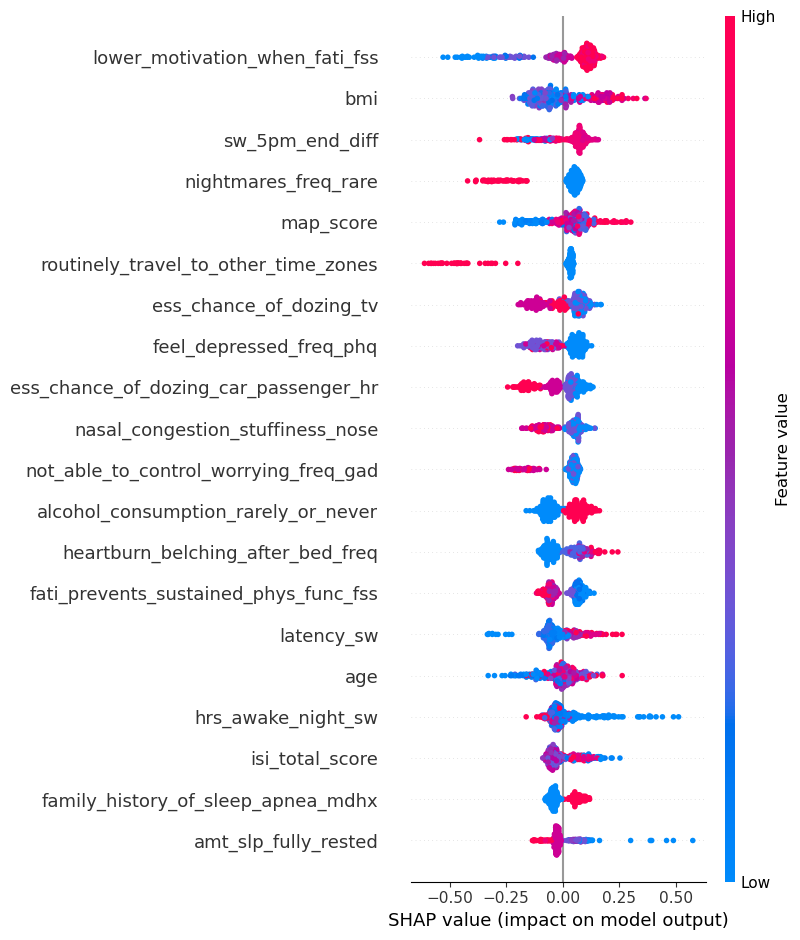

In [7]:
explainer = shap.TreeExplainer(model, X_train_transformed)
shap_values = explainer.shap_values(X_test_transformed)

explanations = explainer(X_test_transformed)

shap.summary_plot(shap_values, X_test_transformed)


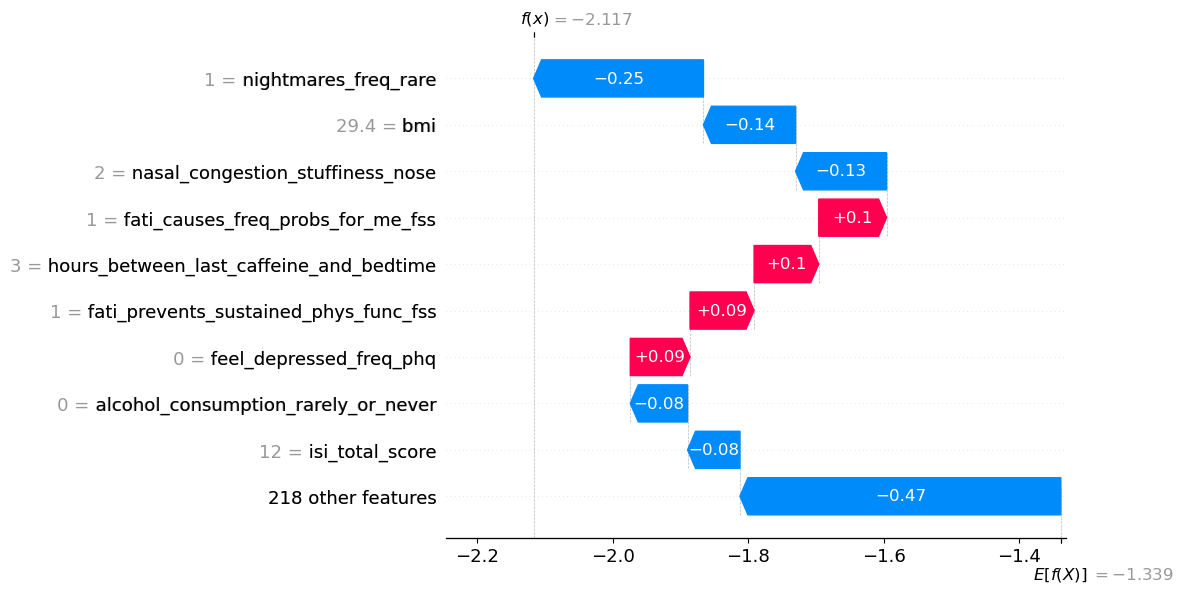

In [10]:
# random ass prediction

shap.plots.waterfall(explanations[1])

In [12]:
from sklearn.feature_selection import RFECV

selector = RFECV(estimator=model, step=1, cv=5, scoring='accuracy')

selector = selector.fit(X_train_transformed, y_train)


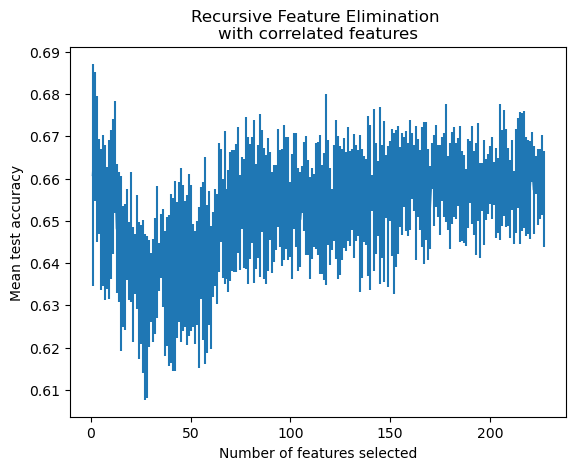

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    key: value
    for key, value in selector.cv_results_.items()
    if key in ["n_features", "mean_test_score", "std_test_score"]
}
cv_results = pd.DataFrame(data)
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()

In [ ]:
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import VarianceThreshold

vt_selector = VarianceThreshold(threshold=0.03)

vt_selector = vt_selector.fit(X_train_transformed)

X_train_vt = vt_selector.transform(X_train_transformed)
X_test_vt = vt_selector.transform(X_test_transformed)



(1427, 213)

In [ ]:
model_selector = SelectFromModel(estimator=model, threshold="median")

model_selector = model_selector.fit(X_train_transformed, y_train)

model_selector.get_support()

X_train_selected = model_selector.transform(X_train_transformed)

X_test_selected = model_selector.transform(X_test_transformed)

X_train_selected.shape
X_train_selected

(1427, 114)

In [ ]:
# TODO: idk train model on both subsets of features and look at shapely stuff from thjere 

vt selected 213 features, select from model has 114

In [24]:
X_train_selected.shape

(1427, 114)

In [25]:
X_train_vt.shape

(1427, 213)

In [26]:
vt_model = xgb.XGBClassifier(random_state=42, n_estimators=1000, max_depth=6, learning_rate=0.01, subsample=0.8, colsample_bytree=0.8)
sfm_model = xgb.XGBClassifier(random_state=42, n_estimators=1000, max_depth=6, learning_rate=0.01, subsample=0.8, colsample_bytree=0.8)

vt_model.fit(X_train_vt, y_train)
sfm_model.fit(X_train_selected, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

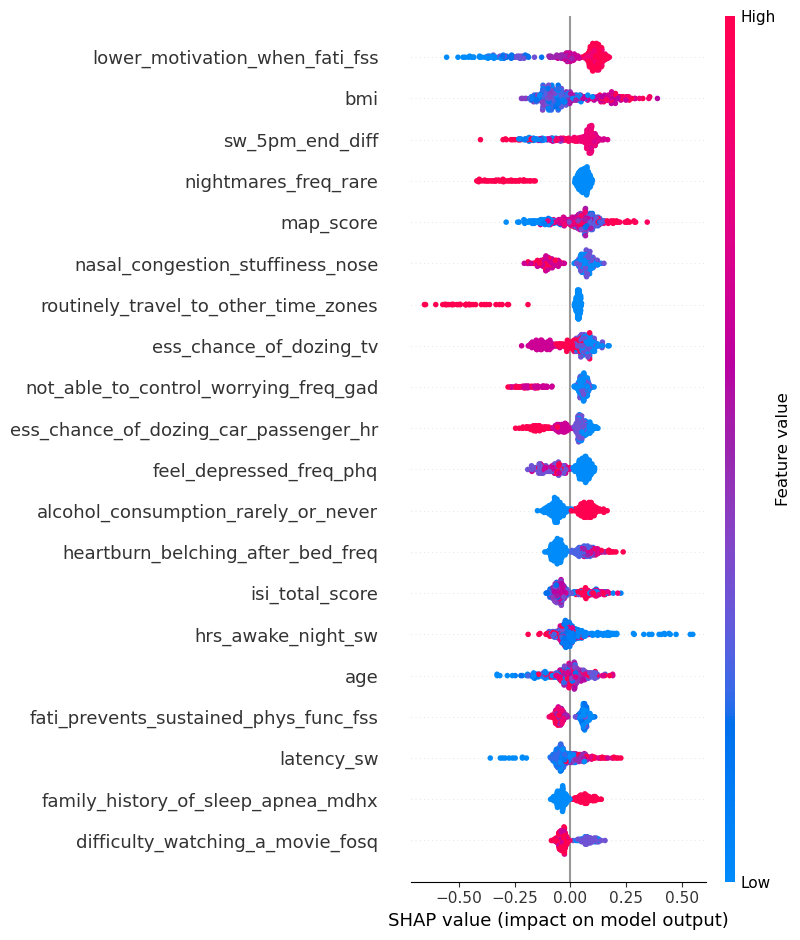

In [30]:
vt_explainer = shap.TreeExplainer(vt_model, X_train_vt)
shap_values = vt_explainer.shap_values(X_test_vt)

explanations = vt_explainer(X_test_vt)

shap.summary_plot(shap_values, X_test_vt)



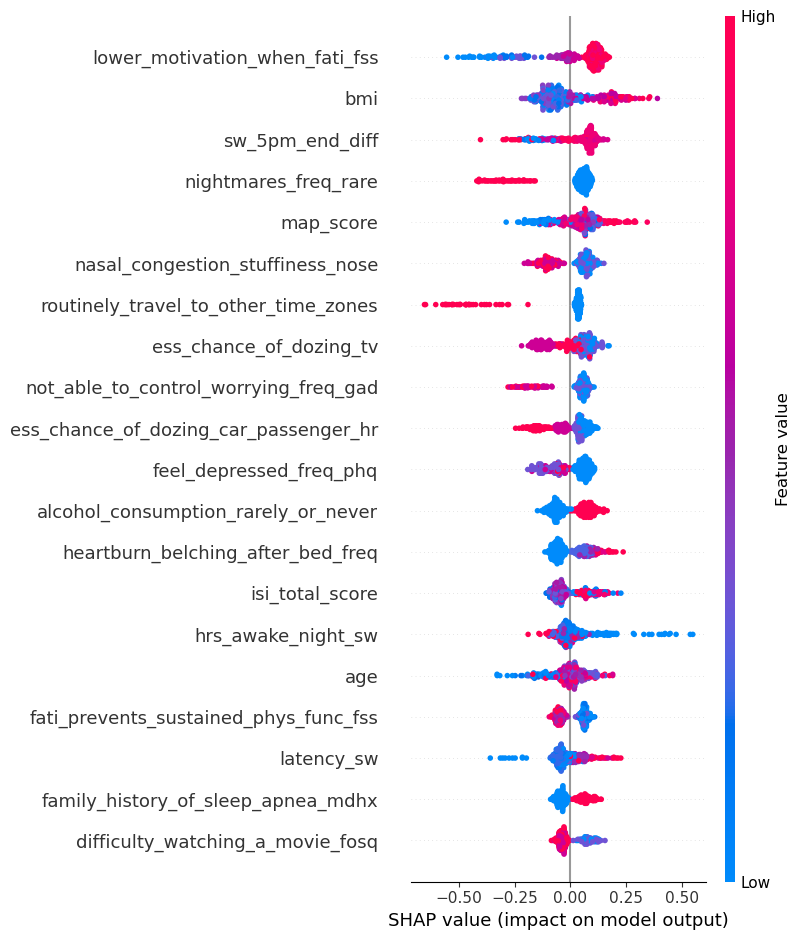

In [31]:
sfm_explainer = shap.TreeExplainer(sfm_model, X_train_selected)
sfm_shap_values = sfm_explainer.shap_values(X_test_selected)

explanations = sfm_explainer(X_test_selected)

shap.summary_plot(shap_values, X_test_vt)



they have determined the same set of features to be important it seems so one just has an extra 100

In [40]:
# find features not in one set

vt_features = X_train_vt.columns.tolist()

sfm_features = X_train_selected.columns.tolist()

diff_features = set(vt_features) - set(sfm_features)

diff_features = list(diff_features)

total_features = set(vt_features).union(set(sfm_features))

total_features = list(total_features)


In [46]:
display(len(vt_features))
display(len(sfm_features))
display(len(total_features))

""" 
2 features are different between the two sets
"""

213

114

215

' \n2 features are different between the two sets\n'

In [48]:
ft = set(total_features) - set(vt_features)

print(ft) #well...

{'family_history_of_death_during_sleep_mdhx', 'num_times_eat_drink_dur_sleep_rare'}


In [ ]:
orig_columns = X_train_transformed.columns.tolist()

missing = set(orig_columns) - set(total_features)
missing = list(missing)

missing # im pretty sure theese are just the features that have no variance or something 

['congestive_heart_failure_mdhx',
 'sleep_attacks_number_of_times_never_unknown',
 'difficulty_staying_awake_during_the_day_number_of_times_never_unknown',
 'nap_num_rare',
 'wakeup_sw_varies',
 'map_likelihood_ration',
 'family_history_of_narcolepsy_mdhx',
 'perform_activities_without_awareness_when_sleepy_number_of_times_never_unknown',
 'bedtime_sw_varies',
 'type_of_pap_device',
 'current_treated_for_narcolepsy',
 'never_feel_rested']

In [53]:
preds = vt_model.predict(X_test_vt)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

         0.0       0.73      0.97      0.83       256
         1.0       0.50      0.08      0.14       101

    accuracy                           0.72       357
   macro avg       0.61      0.52      0.48       357
weighted avg       0.66      0.72      0.63       357



In [55]:
preds = sfm_model.predict(X_test_selected)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

         0.0       0.72      0.95      0.82       256
         1.0       0.37      0.07      0.12       101

    accuracy                           0.70       357
   macro avg       0.55      0.51      0.47       357
weighted avg       0.62      0.70      0.62       357



In [ ]:
# theres no meaningful difference between these two so ima do more feature work

In [94]:
transformed_df = df.copy()

feature_df = transformed_df.drop(columns="ahi")

feature_df = pipeline.transform(feature_df)

""" 
columns that are low variance are result of one hot encoding so gotta encode better basically
"""
feature_df = feature_df.drop(columns=missing) 



/Users/jack/Repos/apnea-predictor/src/features/transformers.py:145: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[False False False ... False True False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X_transformed.loc[:, self.columns] = self.imputer.transform(
/Users/jack/Repos/apnea-predictor/src/features/transformers.py:145: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[False False False ... False False False]' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  X_transformed.loc[:, self.columns] = self.imputer.transform(
/Users/jack/Repos/apnea-predictor/src/features/transformers.py:145: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[True True True ... True False True]' has dtype incompatibl

In [95]:
feature_df = feature_df.drop(columns="routinely_travel_to_other_time_zones") # potentially misleading and had high predictive power 
vim_feature_df = feature_df.copy()

In [96]:
import numpy as np 

corr_matrix = feature_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'correlation'})
    .query('correlation > 0.8')
    .sort_values('correlation', ascending=False)
)
print(high_corr_pairs)

                                               feature_1  \
22044                                              sex_F   
22842                              rls_likely_curr_False   
22989              rls_unlikely_curr_probably_past_False   
22944                            rls_unlikely_curr_False   
22895                            rls_possible_curr_False   
22274                                 bed_partners_False   
17005                            cataplexy_days_per_week   
14983                num_hypnogogic_hallus_days_per_week   
7999                   fati_causes_freq_probs_for_me_fss   
14981                num_hypnogogic_hallus_days_per_week   
8344           fati_interferes_with_responsibilities_fss   
429                                        weight_pounds   
8685            fati_interferes_with_work_fam_social_fss   
17116         map_index_4_narcolepsy_like_symptoms_score   
7825              fati_interferes_with_phys_function_fss   
8515                 fati_top_three_disa

In [97]:
to_drop = set()
for _, row in high_corr_pairs.iterrows():
    f1, f2 = row['feature_1'], row['feature_2']
    # Keep whichever is more correlated with the target
    if abs(feature_df[f1].corr(y)) < abs(feature_df[f2].corr(y)):
        to_drop.add(f1)
    else:
        to_drop.add(f2)
print(f"Drop {len(to_drop)} features:", to_drop)

Drop 26 features: {'rls_unlikely_curr_probably_past_False', 'fati_interferes_with_work_fam_social_fss', 'rls_likely_curr_False', 'map_index_1_apnea_score', 'gad_total_score', 'fati_top_three_disabling_sympts_fss', 'not_able_to_control_worrying_freq_gad', 'num_hypnogogic_hallus_days_per_week', 'fati_causes_freq_probs_for_me_fss', 'fss_total_score', 'weight_pounds', 'rls_unlikely_curr_True', 'rls_possible_curr_True', 'map_index_4_narcolepsy_like_symptoms_score', 'horne_ostberg_morn_or_evening_type', 'how_noticeable_is_sleep_problem_impacting_quality_of_life_isi', 'fati_interferes_with_responsibilities_fss', 'feeling_anxious_freq_gad', 'sleep_paralysis_frequency_score', 'phq_total_score', 'nap_num_frequent', 'bed_partners_True', 'sex_M', 'hh_frequency_score', 'fati_prevents_sustained_phys_func_fss', 'breathing_stops_map'}


In [101]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def drop_high_vif(X, threshold=10.0):
    while True:
        vif = pd.Series(
            [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
            index=X.columns
        )
        max_vif = vif.max()
        if max_vif <= threshold:
            break
        drop_col = vif.idxmax()
        print(f"Dropping {drop_col} (VIF={max_vif:.1f})")
        X = X.drop(columns=[drop_col])
    return X

datetime_cols = feature_df.select_dtypes(include=["datetime", "datetime64"]).columns

feature_df = feature_df.drop(columns= datetime_cols)

X_reduced = drop_high_vif(feature_df)

/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping feeling_anxious_freq_gad (VIF=inf)


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping num_hypnogogic_hallus_days_per_week (VIF=inf)


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping sex_F (VIF=inf)


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping irreg_sched_False (VIF=inf)


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping bed_partners_False (VIF=inf)


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping exercise_amt_or_time_between dinner and bedtime (VIF=inf)


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping street_drug_consume_status_chose no answer (VIF=inf)


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping nightmares_freq_frequent (VIF=inf)


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping rls_likely_curr_False (VIF=inf)


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping rls_possible_curr_False (VIF=inf)


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping rls_unlikely_curr_False (VIF=inf)


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping rls_unlikely_curr_probably_past_False (VIF=inf)


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping num_times_eat_drink_dur_sleep_frequent (VIF=inf)


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping difficulty_falling_asleep_num_isq_frequent (VIF=inf)


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping difficulty_staying_asleep_num_isq_frequent (VIF=inf)


/Users/jack/Repos/apnea-predictor/conda_env/lib/python3.14/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Dropping multiple_awakenings_num_isq_frequent (VIF=inf)
Dropping map_index_1_apnea_score (VIF=644430081901.8)
Dropping map_index_3_excessive_daytime_sleepiness_ (VIF=310775256348.2)
Dropping fss_total_score (VIF=250516.1)
Dropping ess_total_score (VIF=112010.7)
Dropping isi_total_score (VIF=49208.4)
Dropping phq_total_score (VIF=3241.2)
Dropping remember_dreams_times_frequent (VIF=2082.9)
Dropping height_inches (VIF=904.1)
Dropping cataplexy_days_per_week (VIF=454.4)
Dropping gad_total_score (VIF=212.6)
Dropping bmi (VIF=192.3)
Dropping rls_unlikely_curr_True (VIF=118.0)
Dropping nap_num_frequent (VIF=75.8)
Dropping difficulty_operating_motor_vehicles_for_short_distances_fosq (VIF=71.0)
Dropping rmeq_total_score (VIF=69.6)
Dropping amt_slp_fully_rested (VIF=69.6)
Dropping map_index_4_narcolepsy_like_symptoms_score (VIF=64.0)
Dropping difficulty_staying_asleep_num_isq_rare (VIF=56.9)
Dropping rls_severity_current (VIF=48.8)
Dropping weight_pounds (VIF=45.4)
Dropping difficulty_visiting_

In [ ]:
X_reduced.shape

""" 
i think i am going to try to combine some correlated features and return to this

"""

(1784, 140)